# I - Préliminaires - Fonctions utiles

In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import itertools
import numpy as np
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Matrice de confusion',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    from http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html
    :param cm: (numpy matrix) confusion matrix
    :param classes: [str]
    :param normalize: (bool)
    :param title: (str)
    :param cmap: (matplotlib color map)
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
    plt.figure(figsize=(8, 8))   
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')

# II - Entraînement d'un CNN pour la classification sur CIFAR10

### II.1. Chargement et Dimensionnement de la base CIFAR10

In [3]:
from keras import backend as K
print(K.backend())

tensorflow


In [4]:
from keras.datasets import cifar10

Réduction de la taille du dataset (pour accélérer l'apprentissage), et standardisation des données

In [5]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = cifar10.load_data()
print("Dimension de la base d'apprentissage CIFAR10 :",x_train_full.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train_full.shape)
print("Dimension de la base de test CIFAR10 :",x_test_full.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 137s 1us/step
Dimension de la base d'apprentissage CIFAR10 : (50000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (50000, 1)
Dimension de la base de test CIFAR10 : (10000, 32, 32, 3)


In [6]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [7]:
n_training_samples = 5000
n_other_samples = 2000

def standardize(img_data):
    img_data_mean = np.mean(img_data, axis=(1,2), keepdims=True)
    img_data_std = np.std(img_data, axis=(1,2), keepdims=True)
    img_data = (img_data - img_data_mean) / img_data_std
    return img_data

train_ids = np.random.choice(len(x_train_full), size=n_training_samples, replace=False)
other_ids = np.random.choice(len(x_test_full), size=n_other_samples, replace=False)

n_valid = n_other_samples // 2
val_ids = other_ids[:n_valid]
test_ids = other_ids[n_valid:]

x_train_initial, y_train = x_train_full[train_ids], y_train_full[train_ids]
x_val_initial, y_val = x_test_full[val_ids], y_test_full[val_ids]
x_test_initial, y_test = x_test_full[test_ids], y_test_full[test_ids]

x_train = standardize(x_train_initial)
x_val = standardize(x_val_initial)
x_test = standardize(x_test_initial)

print("Dimension de notre base d'apprentissage :",x_train.shape)
print("Dimension des vecteurs d'étiquette de classe :",y_train.shape)
print("Dimension de notre base de validation :",x_val.shape)
print("Dimension de notre base de test :",x_test.shape)


Dimension de notre base d'apprentissage : (5000, 32, 32, 3)
Dimension des vecteurs d'étiquette de classe : (5000, 1)
Dimension de notre base de validation : (1000, 32, 32, 3)
Dimension de notre base de test : (1000, 32, 32, 3)


On affiche quelques images d'entraînement avec leur étiquette...

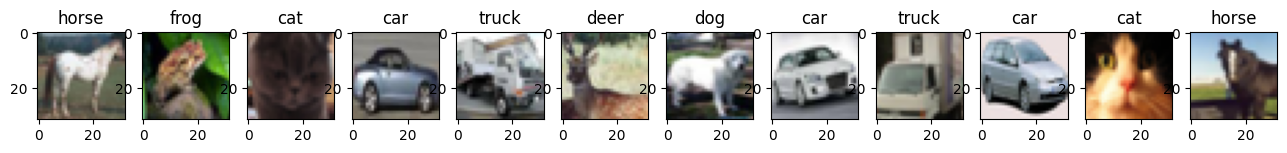

In [8]:
n_display = 12
random_ids = np.random.choice(len(x_train), n_display, replace=False)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_train_initial[random_ids[k]])
    axarr[k].title.set_text(classes[y_train[random_ids[k]][0]])

In [9]:
from keras.utils import to_categorical
y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print("Dimension des matrices d'étiquette de classe (train) :",y_train.shape)
print("Dimension des matrices d'étiquette de classe (val) :",y_val.shape)
print("Dimension des matrices d'étiquette de classe (test) :",y_test.shape)

Dimension des matrices d'étiquette de classe (train) : (5000, 10)
Dimension des matrices d'étiquette de classe (val) : (1000, 10)
Dimension des matrices d'étiquette de classe (test) : (1000, 10)


### II.2. Definition de l'architecture du CNN

Un simple réseau convolutionnel... 

In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Activation
from keras.regularizers import l2
from keras import Input

model = Sequential()
model.add(Input(shape = (32,32,3)))
model.add(Conv2D(filters=8, 
                kernel_size = (3, 3),
                activation = 'relu',
                padding = 'same',
                kernel_regularizer = l2(0.00)))
model.add(Dropout(0.0))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu', kernel_regularizer = l2(0.00)))
model.add(Dropout(0.0))
model.add(Dense(10, activation='softmax', kernel_regularizer = l2(0.00)))
model.add(Dropout(0.0))

On enregistre les poids initiaux pour plus tard...

In [11]:
weights_init = model.get_weights()

### II.3. Definition de la fonction de coût et choix de l'algorithme d'optimisation

In [12]:
from keras.optimizers import Adam, SGD

opt = SGD(learning_rate=0.01,momentum=0.0)
# opt = Adam(lr=0.001)
model.compile(optimizer=opt,
             loss='categorical_crossentropy',
             metrics=['acc'])

On affiche un résumé de la structure du modèle...

In [24]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 8)           │             224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 8)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10)                  │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 132,010 (515.66 KB)

 Trainable params: 132,010 (515.66 KB)

 Non-trainable params: 0 (0.00 B)

None


### II.4. Entraînement du CNN

*Definition du callback. A passer en première lecture.*

In [14]:
from keras.callbacks import Callback
from keras.callbacks import ModelCheckpoint
import time

class TimeHistory(Callback):
    def on_train_begin(self, logs={}):
        self.times = []

    def on_epoch_begin(self, batch, logs={}):
        self.epoch_time_start = time.time()

    def on_epoch_end(self, batch, logs={}):
        self.times.append(time.time() - self.epoch_time_start)
time_callback = TimeHistory()
filepath = "my_model.h5"
checkpoint = ModelCheckpoint(filepath, monitor='val_acc', verbose=1, save_best_only=True, mode='max', save_freq=2)

callbacks = [time_callback, checkpoint]

In [15]:
history = model.fit(x_train, y_train, batch_size=32, epochs=20, verbose=1, validation_data=(x_val, y_val),
                    callbacks=callbacks)

Epoch 1/20
  1/157 ━━━━━━━━━━━━━━━━━━━━ 2:26 940ms/step - acc: 0.2188 - loss: 2.4097

Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\.venv\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):



Epoch 1: finished saving model to my_model.h5
  2/157 ━━━━━━━━━━━━━━━━━━━━ 12s 81ms/step - acc: 0.2109 - loss: 2.3705  


Epoch 1: finished saving model to my_model.h5
  5/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - acc: 0.1966 - loss: 2.3915 


Epoch 1: finished saving model to my_model.h5
  6/157 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - acc: 0.1968 - loss: 2.3901

...


Epoch 20: finished saving model to my_model.h5



Epoch 20: finished saving model to my_model.h5
151/157 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.8691 - loss: 0.4458


Epoch 20: finished saving model to my_model.h5



Epoch 20: finished saving model to my_model.h5
155/157 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - acc: 0.8688 - loss: 0.4464


Epoch 20: finished saving model to my_model.h5
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - acc: 0.8578 - loss: 0.4694 - val_acc: 0.3990 - val_loss: 2.5120


### II.4.b. Campagne comparative de la Section 4 du rapport

La campagne comparative d?taill?e sur la taille du batch et sur les optimiseurs est d?sormais orchestr?e dans la Section V du notebook. Les d?tails d'impl?mentation sont d?plac?s dans `scripts/section4_pipeline.py` et `scripts/section4_visualization.py`, tandis que le notebook conserve les appels principaux, les r?sultats agr?g?s et les observations associ?es.

Statistiques sur le temps d'entraînement d'une epoch

In [17]:
times = time_callback.times
print("Mean: {}".format(np.mean(times)))
print("Std: {}".format(np.std(times)))

Mean: 3.6323954582214357
Std: 0.4327443474648175


Tracé des courbes d'évolution des fonctions de coût

In [18]:
history.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

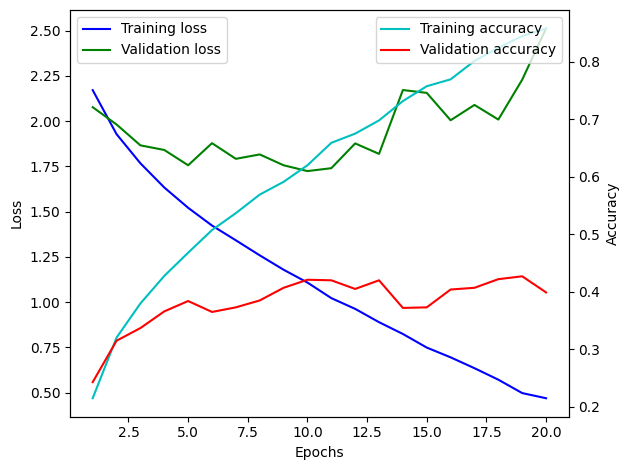

In [19]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']

epochs = range(1, len(history_dict['acc']) + 1)

fig, ax1 = plt.subplots()
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.plot(epochs, loss_values, color='b', label='Training loss')
ax1.plot(epochs, val_loss_values, color='g', label='Validation loss')
ax1.tick_params(axis='y')
plt.legend()

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

ax2.set_ylabel('Accuracy')  # we already handled the x-label with ax1
ax2.plot(epochs, acc_values, color='c', label='Training accuracy')
ax2.plot(epochs, val_acc_values, color='r', label='Validation accuracy')
ax2.tick_params(axis='y')

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.legend(loc=1)
plt.show()

### II.5. Entraînement d'un CNN avec points d'arrêt et reprises (à passer en première lecture)

Pour des entraînements plus conséquents, il est primordial d'enregistrer les modèles intermédiaires afin de ne pas tout perdre si l'apprentissage venait à s'interrompre de façon impromptue. On peut enregistrer le modèle dans un fichier .hdf

Si vous regardez plus attentivement, lors de l'entrainement précédent nous avons crée un object **ModelCheckpoint**. Il permet d'enregistrer le meilleur modèle (au sens d'une metrique à préciser) dans un fichier nommé *my_model.h5*. Verifiez que ce fichier se trouve bien votre espace de travail.

L'argument ***period*** de l'objet ModelCheckpoint vous permet de definir la fréquence des enregistrements.

In [ ]:
from keras.models import load_model

Une fois le modele obtenu, on peut l'enregister et le recharger comme ceci: load_model(filepath)

In [ ]:
from keras.models import load_model

import pathlib
file = pathlib.Path(filepath)
if file.exists():
    model = load_model(filepath)
else:
    model.set_weights(weights_init)
    callbacks = [time_callback,checkpoint]
history_2 = model.fit(x_train, y_train, batch_size=8, epochs=10, verbose=1, validation_data=(x_val, y_val),
                      callbacks = callbacks)

# III - Test et Évaluation du modèle en prédiction

### III.1. Test du modèle sur les données de test

Testons la prédiction de notre modèle sur quelques images de test au hasard...

In [ ]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
pred = np.argmax(model.predict(x_test[random_ids]), axis=1)
f, axarr = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    axarr[k].imshow(x_test_initial[random_ids[k]])
    axarr[k].title.set_text(classes[pred[k]])

Vos premiers résultats semblent-ils corrects ?

Hum ! Affichons à présent la précision sur l'ensemble de votre base :

In [ ]:
print("Précision du réseau sur les {} images d'entraînement : {:.2f} %".format(n_training_samples, 100 * history_dict['acc'][-1]))
print("Précision du réseau sur les {} images de validation : {:.2f} %".format(n_valid, 100 * history_dict['val_acc'][-1]))

In [ ]:
def accuracy_per_class(model):
    n_classes = len(classes)
    confusion_matrix = np.zeros((n_classes, n_classes), dtype=np.int64)
    
    pred = np.argmax(model.predict(x_test), axis=1)
    for i in range(len(y_test)):
        confusion_matrix[np.argmax(y_test[i]), pred[i]] += 1
    
    print("{:<10} {:^10}".format("Classe", "Précision (%)"))
    total_correct = 0
    for i in range(n_classes):
        class_total = confusion_matrix[i, :].sum()
        class_correct = confusion_matrix[i, i]
        total_correct += class_correct
        percentage_correct = 100.0 * float(class_correct) / class_total
        print('{:<10} {:^10.2f}'.format(classes[i], percentage_correct))
    test_acc = 100.0 * float(total_correct) / len(y_test)
    print("Précision du réseau sur les {} images de test : {:.2f} %".format(len(y_test),test_acc))
    return confusion_matrix

confusion_matrix = accuracy_per_class(model)

### III.2. Matrices de Confusion

Les matrices de confusion nous renseignent plus précisément sur la nature des erreurs commises par notre modèle.

In [ ]:
# Plot normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes, normalize=True,
                      title='Matrice de confusion normalisée')

# Plot non-normalized confusion matrix
plot_confusion_matrix(confusion_matrix, classes,
                      title='Matrice de confusion non normalisée')

# IV - Visualisation des zones d'activation

In [ ]:
from keras.models import Model

reduced_model = Model(inputs=model.inputs, outputs=model.layers[1].output)
reduced_model.summary()

In [ ]:
feature_maps = reduced_model.predict(x_test)

In [ ]:
def get_mask(k):
    feature_maps_positive = np.maximum(feature_maps[k], 0)
    mask = np.sum(feature_maps_positive,axis=2)
    mask = mask / np.max(mask)
    return mask

In [ ]:
random_ids = np.random.choice(len(x_test), n_display, replace=False)
f, rd_img = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    img = x_test_initial[random_ids[k]]
    rd_img[k].imshow(img)
    rd_img[k].axis('off')
f, rd_maps = plt.subplots(1,n_display,figsize=(16,16))
for k in range(n_display):
    mask = get_mask(random_ids[k])
    rd_maps[k].imshow(mask)
    rd_maps[k].axis('off')

# V - Campagne expérimentale pour la Section 4 du rapport

Cette section orchestre les expériences utilisés dans la r?daction de la Section 4 du rapport. Le notebook expose le protocole, appelle les fonctions utilitaires stock?es dans `scripts/`, recharge les r?sultats agr?g?s et affiche les figures retenues pour l'analyse.

In [1]:
from IPython.display import Image, Markdown, display

from scripts.section4_pipeline import (
    BATCH_SIZES,
    BATCH_STUDY_EPOCHS,
    DEFAULT_RESULTS_PATH,
    OPTIMIZER_BATCH_SIZE,
    OPTIMIZER_CONFIGS,
    OPTIMIZER_STUDY_EPOCHS,
    TRAINING_SEEDS,
    get_section4_protocol,
    run_section4_pipeline,
)
from scripts.section4_visualization import (
    DEFAULT_FIGURE_DIR,
    format_batch_summary_markdown,
    format_optimizer_summary_markdown,
    format_protocol_markdown,
    load_image_paths,
    save_all_section4_figures,
)

In [2]:
section4_protocol = get_section4_protocol()
display(Markdown("### V.1. Protocole retenu"))
display(Markdown(format_protocol_markdown(section4_protocol)))

print("Batch sizes test?s :", BATCH_SIZES)
print("Optimiseurs compar?s :", [config["name"] for config in OPTIMIZER_CONFIGS])
print("Graines d'entra?nement :", TRAINING_SEEDS)
print("Nombre d'epochs (batch size) :", BATCH_STUDY_EPOCHS)
print("Nombre d'epochs (optimiseurs) :", OPTIMIZER_STUDY_EPOCHS)
print("Batch size fixe pour la comparaison d'optimiseurs :", OPTIMIZER_BATCH_SIZE)

results_path = DEFAULT_RESULTS_PATH
figure_dir = DEFAULT_FIGURE_DIR
force_recompute = False  # True recomputes the full campaign from the notebook.

### V.1. Protocole retenu

| Parametre | Valeur |
| --- | --- |
| Sections de reference | Section II pour les donn?es et la standardisation, Section III pour l'architecture |
| Sous-ensembles | 5000 train / 1000 validation / 1000 test |
| Graine de partition | 42 |
| Graines d'entrainement | 42, 314 |
| Comparaison batch size | 8 epochs fixes, batch sizes 8, 16, 32, 64, 128 |
| Comparaison optimiseurs | 8 epochs fixes, batch size 32 |
| SGD | lr=0.01, momentum=0.0 |
| SGD+Momentum | lr=0.01, momentum=0.9 |
| Adam | lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07 |
| Convention de loss | sum_over_batch_size |
| Temps/step | mean over the recorded training-batch wall times |
| Temps/epoch | per-epoch wall time including validation |

Batch sizes test?s : [8, 16, 32, 64, 128]
Optimiseurs compar?s : ['SGD', 'SGD+Momentum', 'Adam']
Graines d'entra?nement : [42, 314]
Nombre d'epochs (batch size) : 8
Nombre d'epochs (optimiseurs) : 8
Batch size fixe pour la comparaison d'optimiseurs : 32


In [3]:
section4_results = run_section4_pipeline(
    output_path=results_path,
    force_recompute=force_recompute,
    verbose=True,
)
section4_figures = save_all_section4_figures(section4_results, figure_dir=figure_dir)

print(f"R?sultats agr?g?s : {results_path}")
for name, figure_path in section4_figures.items():
    print(f"{name}: {figure_path}")

Loading existing Section 4 results from Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\results\section4\section4_results.json


R?sultats agr?g?s : Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\results\section4\section4_results.json
batch_step_time: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_batch_step_time.png
batch_epoch_time: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_batch_epoch_time.png
batch_curves: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_batch_curves.png
optimizer_curves: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_optimizer_curves.png
optimizer_summary: Z:\Proyectos\Data\Computer Vision\cifar10-cnn-classification\docs\rappport\imgs\section4_optimizer_summary.png


In [4]:
display(Markdown("### V.2. Synth?se agr?g?e : taille du batch"))
display(Markdown(format_batch_summary_markdown(section4_results)))

display(Markdown("### V.3. Synth?se agr?g?e : optimiseurs"))
display(Markdown(format_optimizer_summary_markdown(section4_results)))

### V.2. Synth?se agr?g?e : taille du batch

| Batch size | Steps/epoch | Temps/step (s) | Temps/epoch (s) | Accuracy finale val. (%) | Min. val. loss |
| --- | --- | --- | --- | --- | --- |
| 8 | 625 | 0.0050 ± 0.0098 | 3.692 ± 0.463 | 42.55 | 1.6833 |
| 16 | 313 | 0.0072 ± 0.0123 | 2.695 ± 0.442 | 41.80 | 1.7038 |
| 32 | 157 | 0.0111 ± 0.0162 | 2.102 ± 0.375 | 38.60 | 1.7584 |
| 64 | 79 | 0.0183 ± 0.0225 | 1.766 ± 0.311 | 35.35 | 1.8489 |
| 128 | 40 | 0.0355 ± 0.0453 | 1.735 ± 0.441 | 30.65 | 1.9489 |

### V.3. Synth?se agr?g?e : optimiseurs

| Optimiseur | Temps/epoch (s) | Accuracy finale val. (%) | Min. val. loss |
| --- | --- | --- | --- |
| SGD | 2.278 ± 0.330 | 38.60 | 1.7584 |
| SGD+Momentum | 2.164 ± 0.408 | 40.20 | 1.7079 |
| Adam | 2.151 ± 0.522 | 43.45 | 1.6083 |

### V.4. Figures utilis?es dans la Section 4

**Temps moyen par step selon la taille du batch**

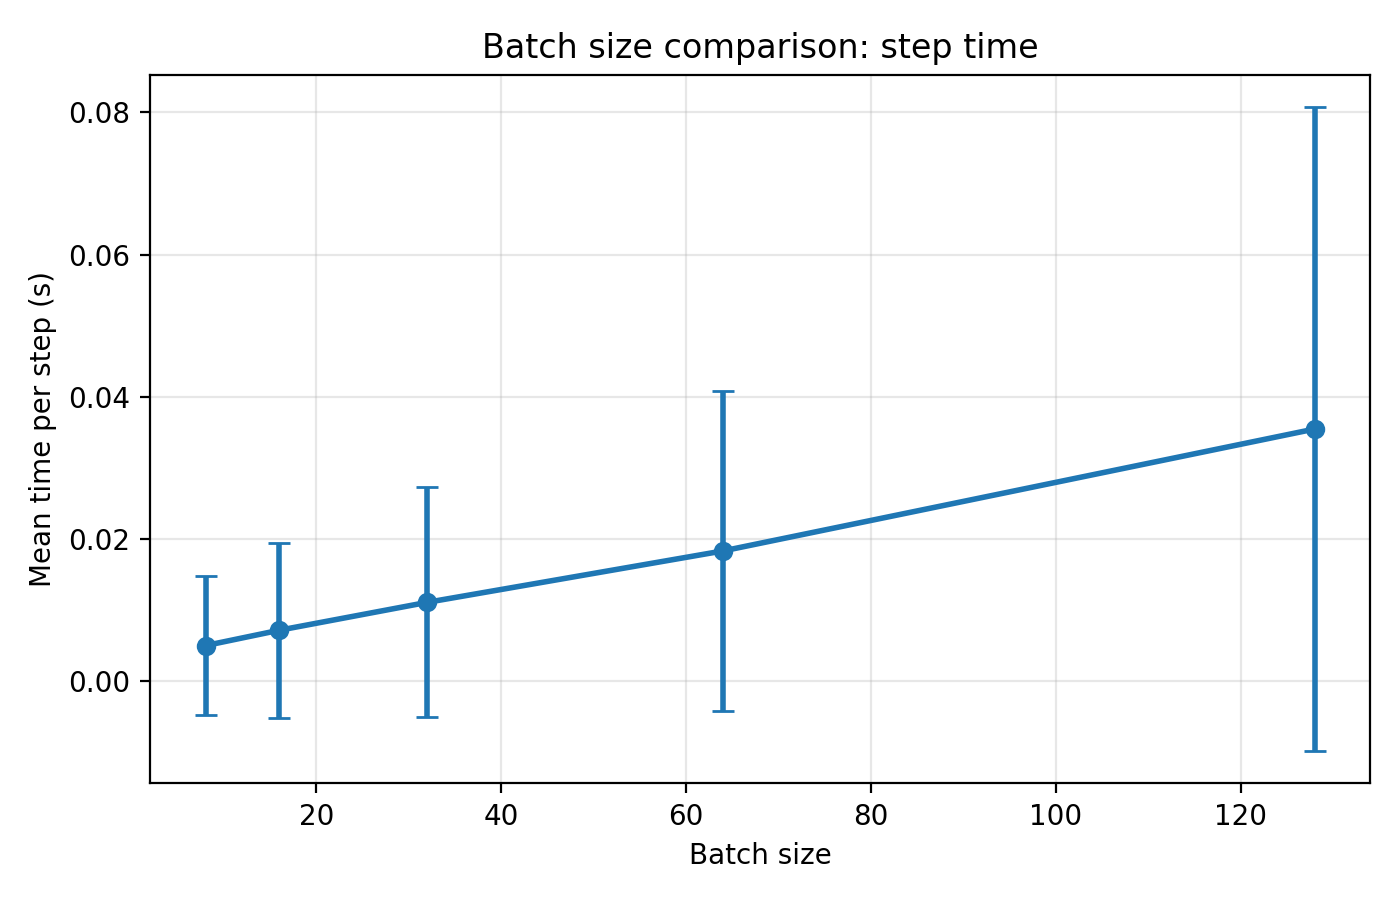

**Temps moyen par epoch selon la taille du batch**

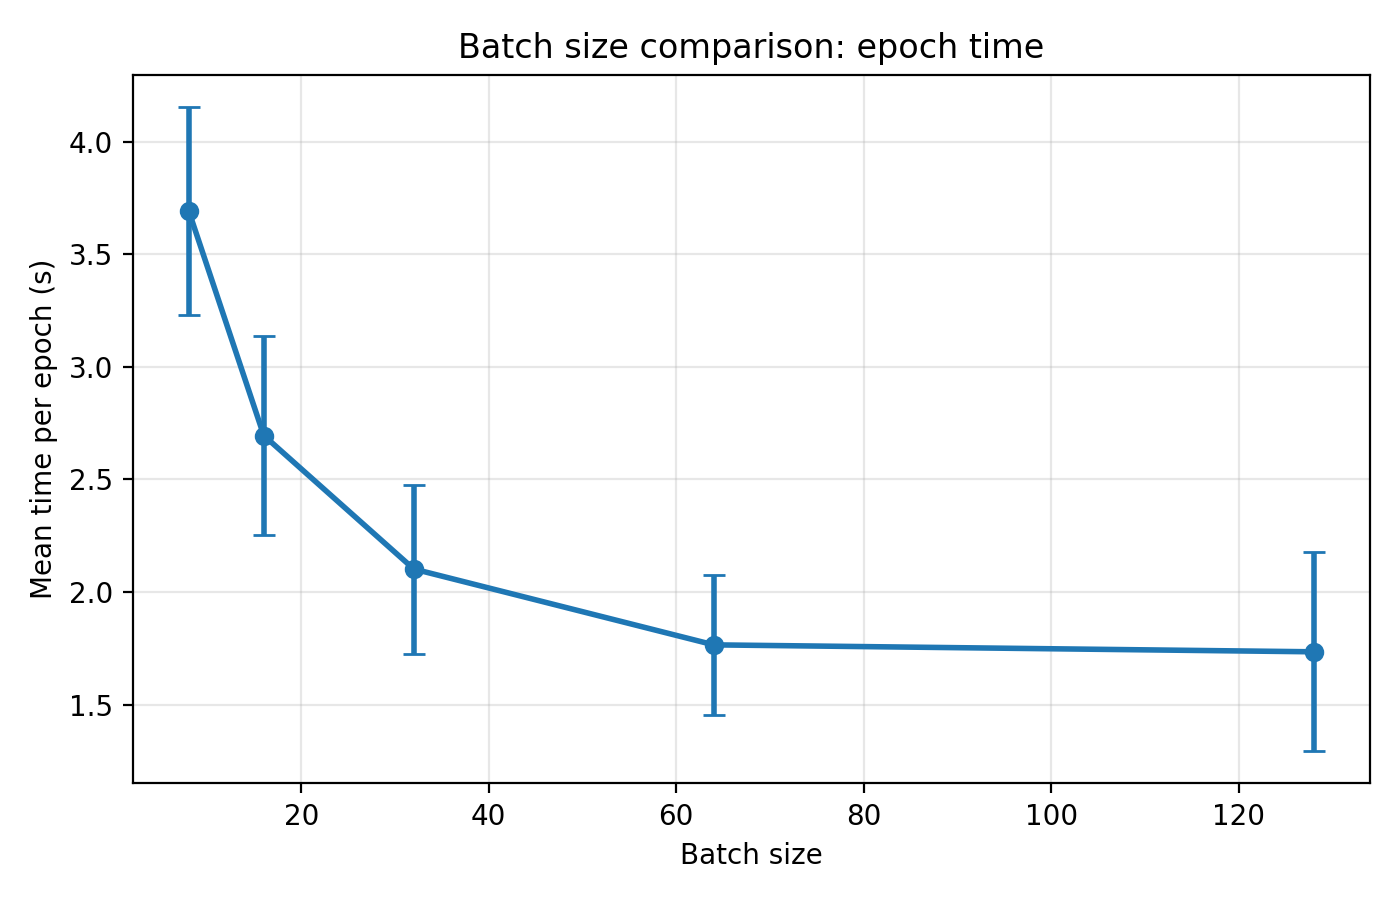

**Courbes d'apprentissage pour les batch sizes test?s**

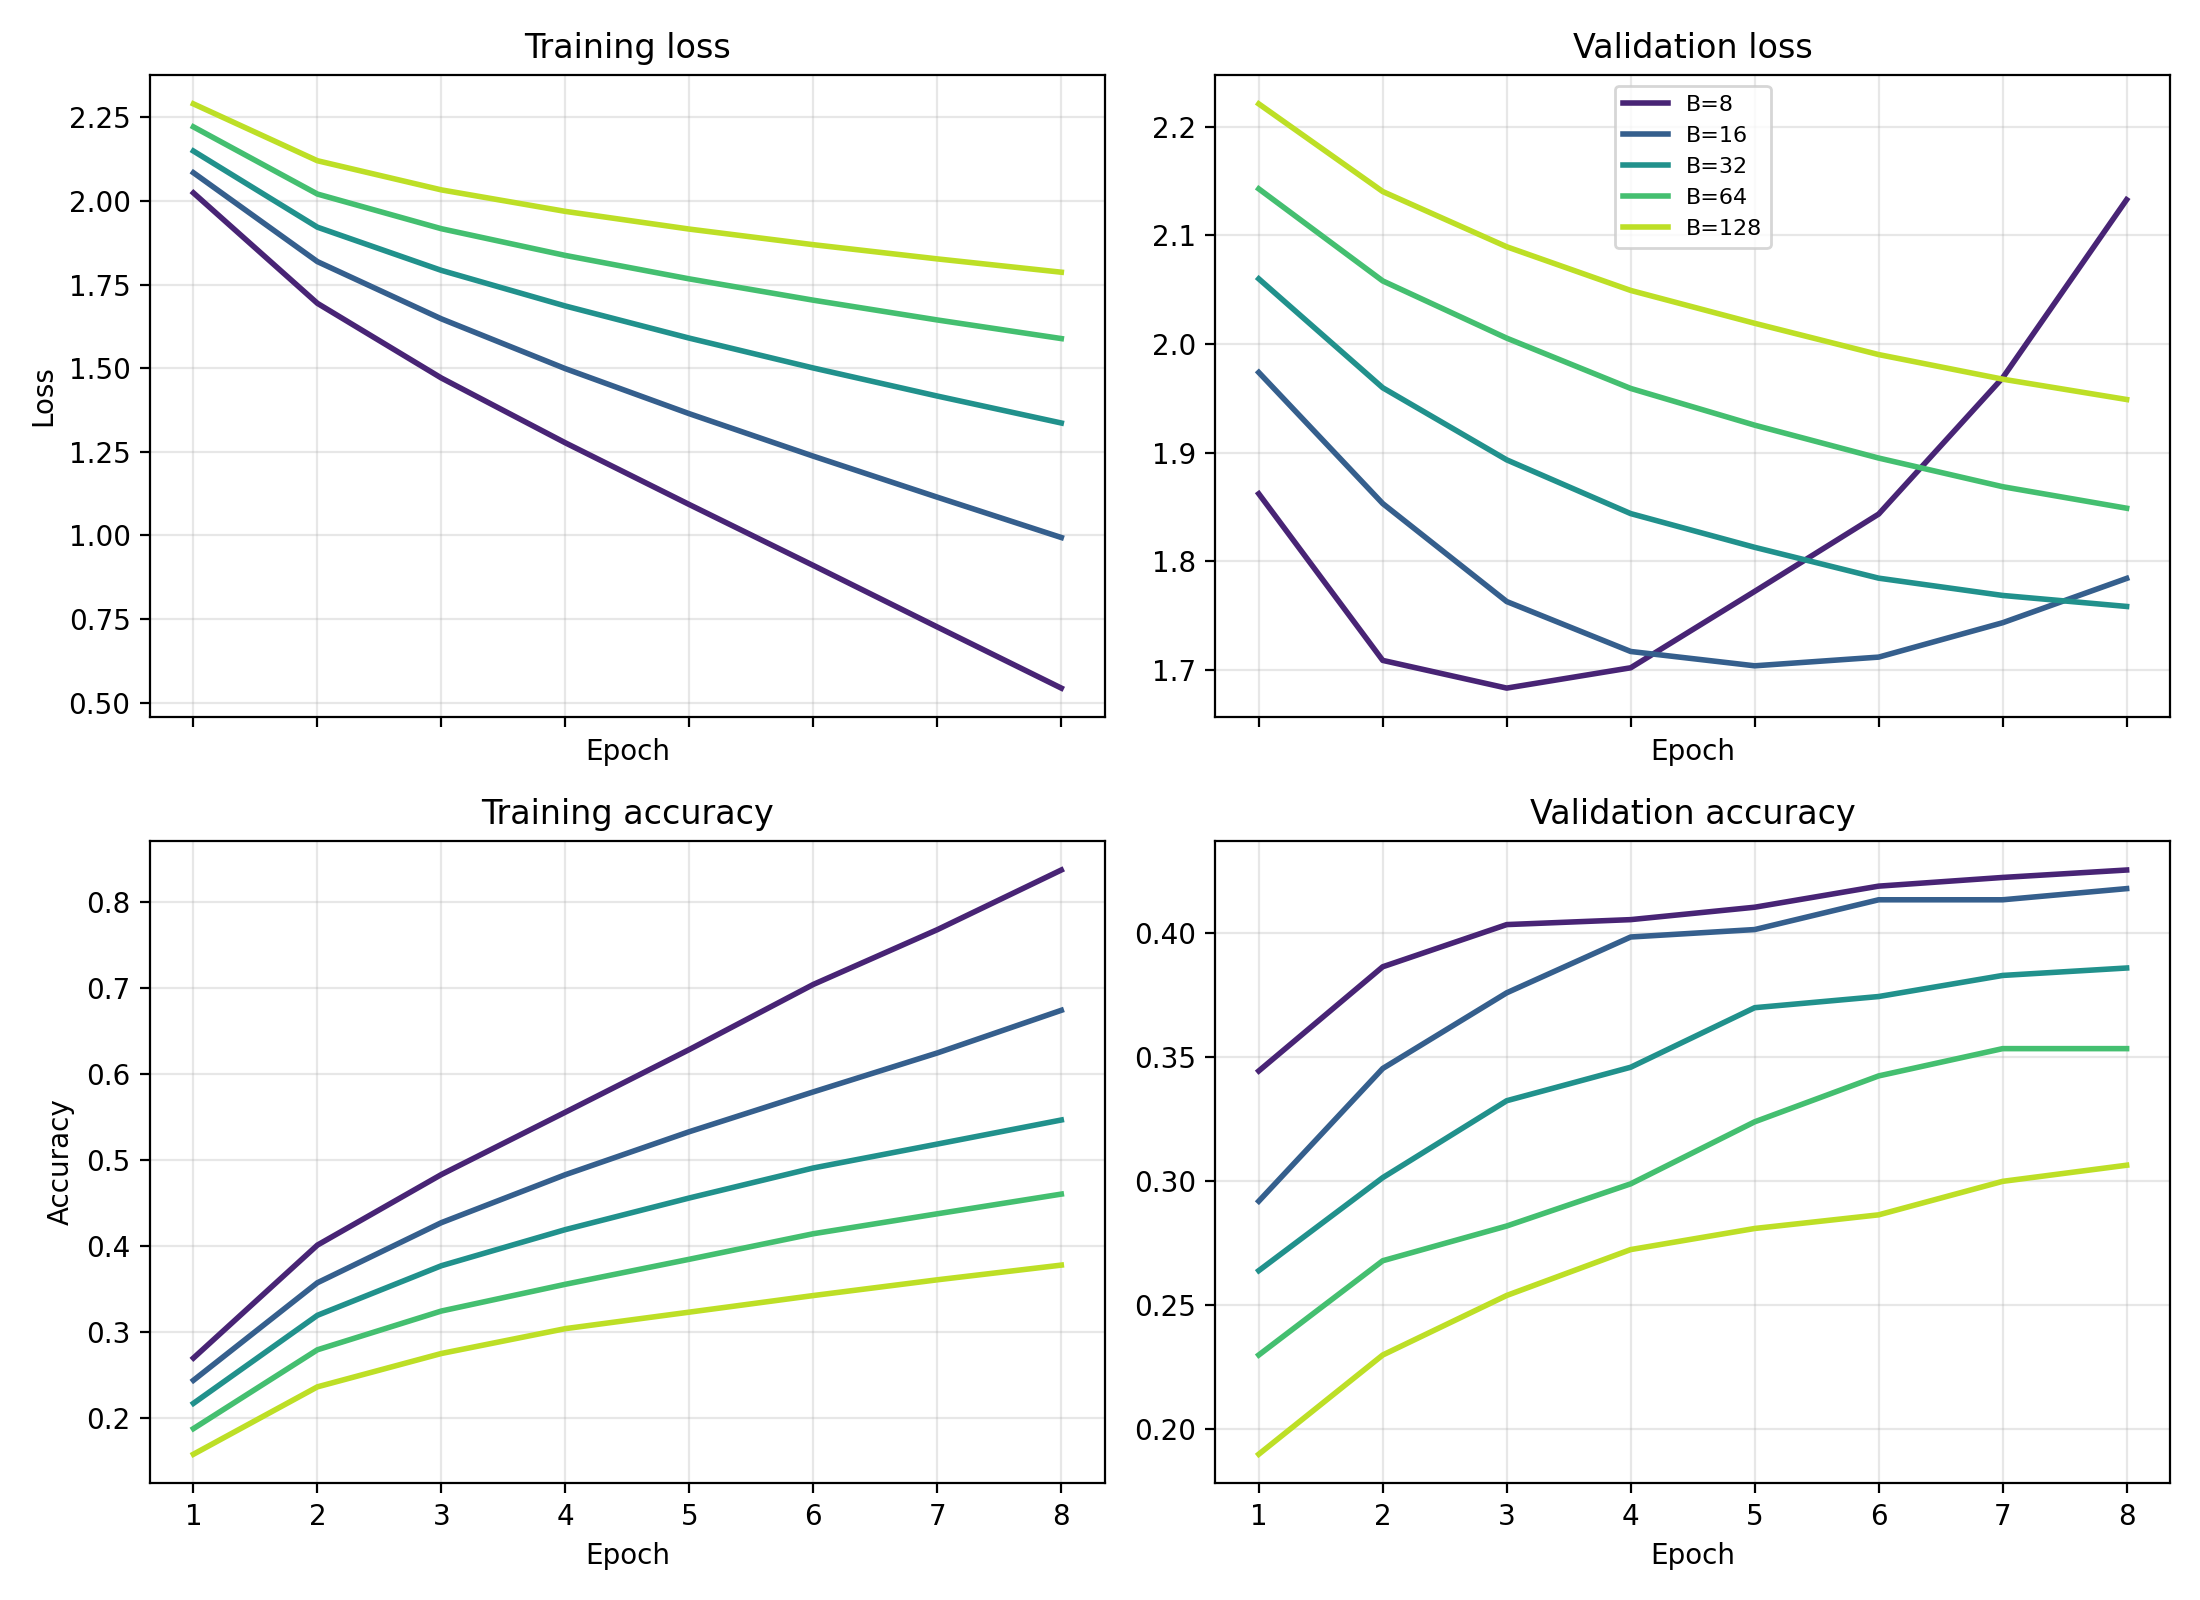

**Courbes d'apprentissage pour les optimiseurs compar?s**

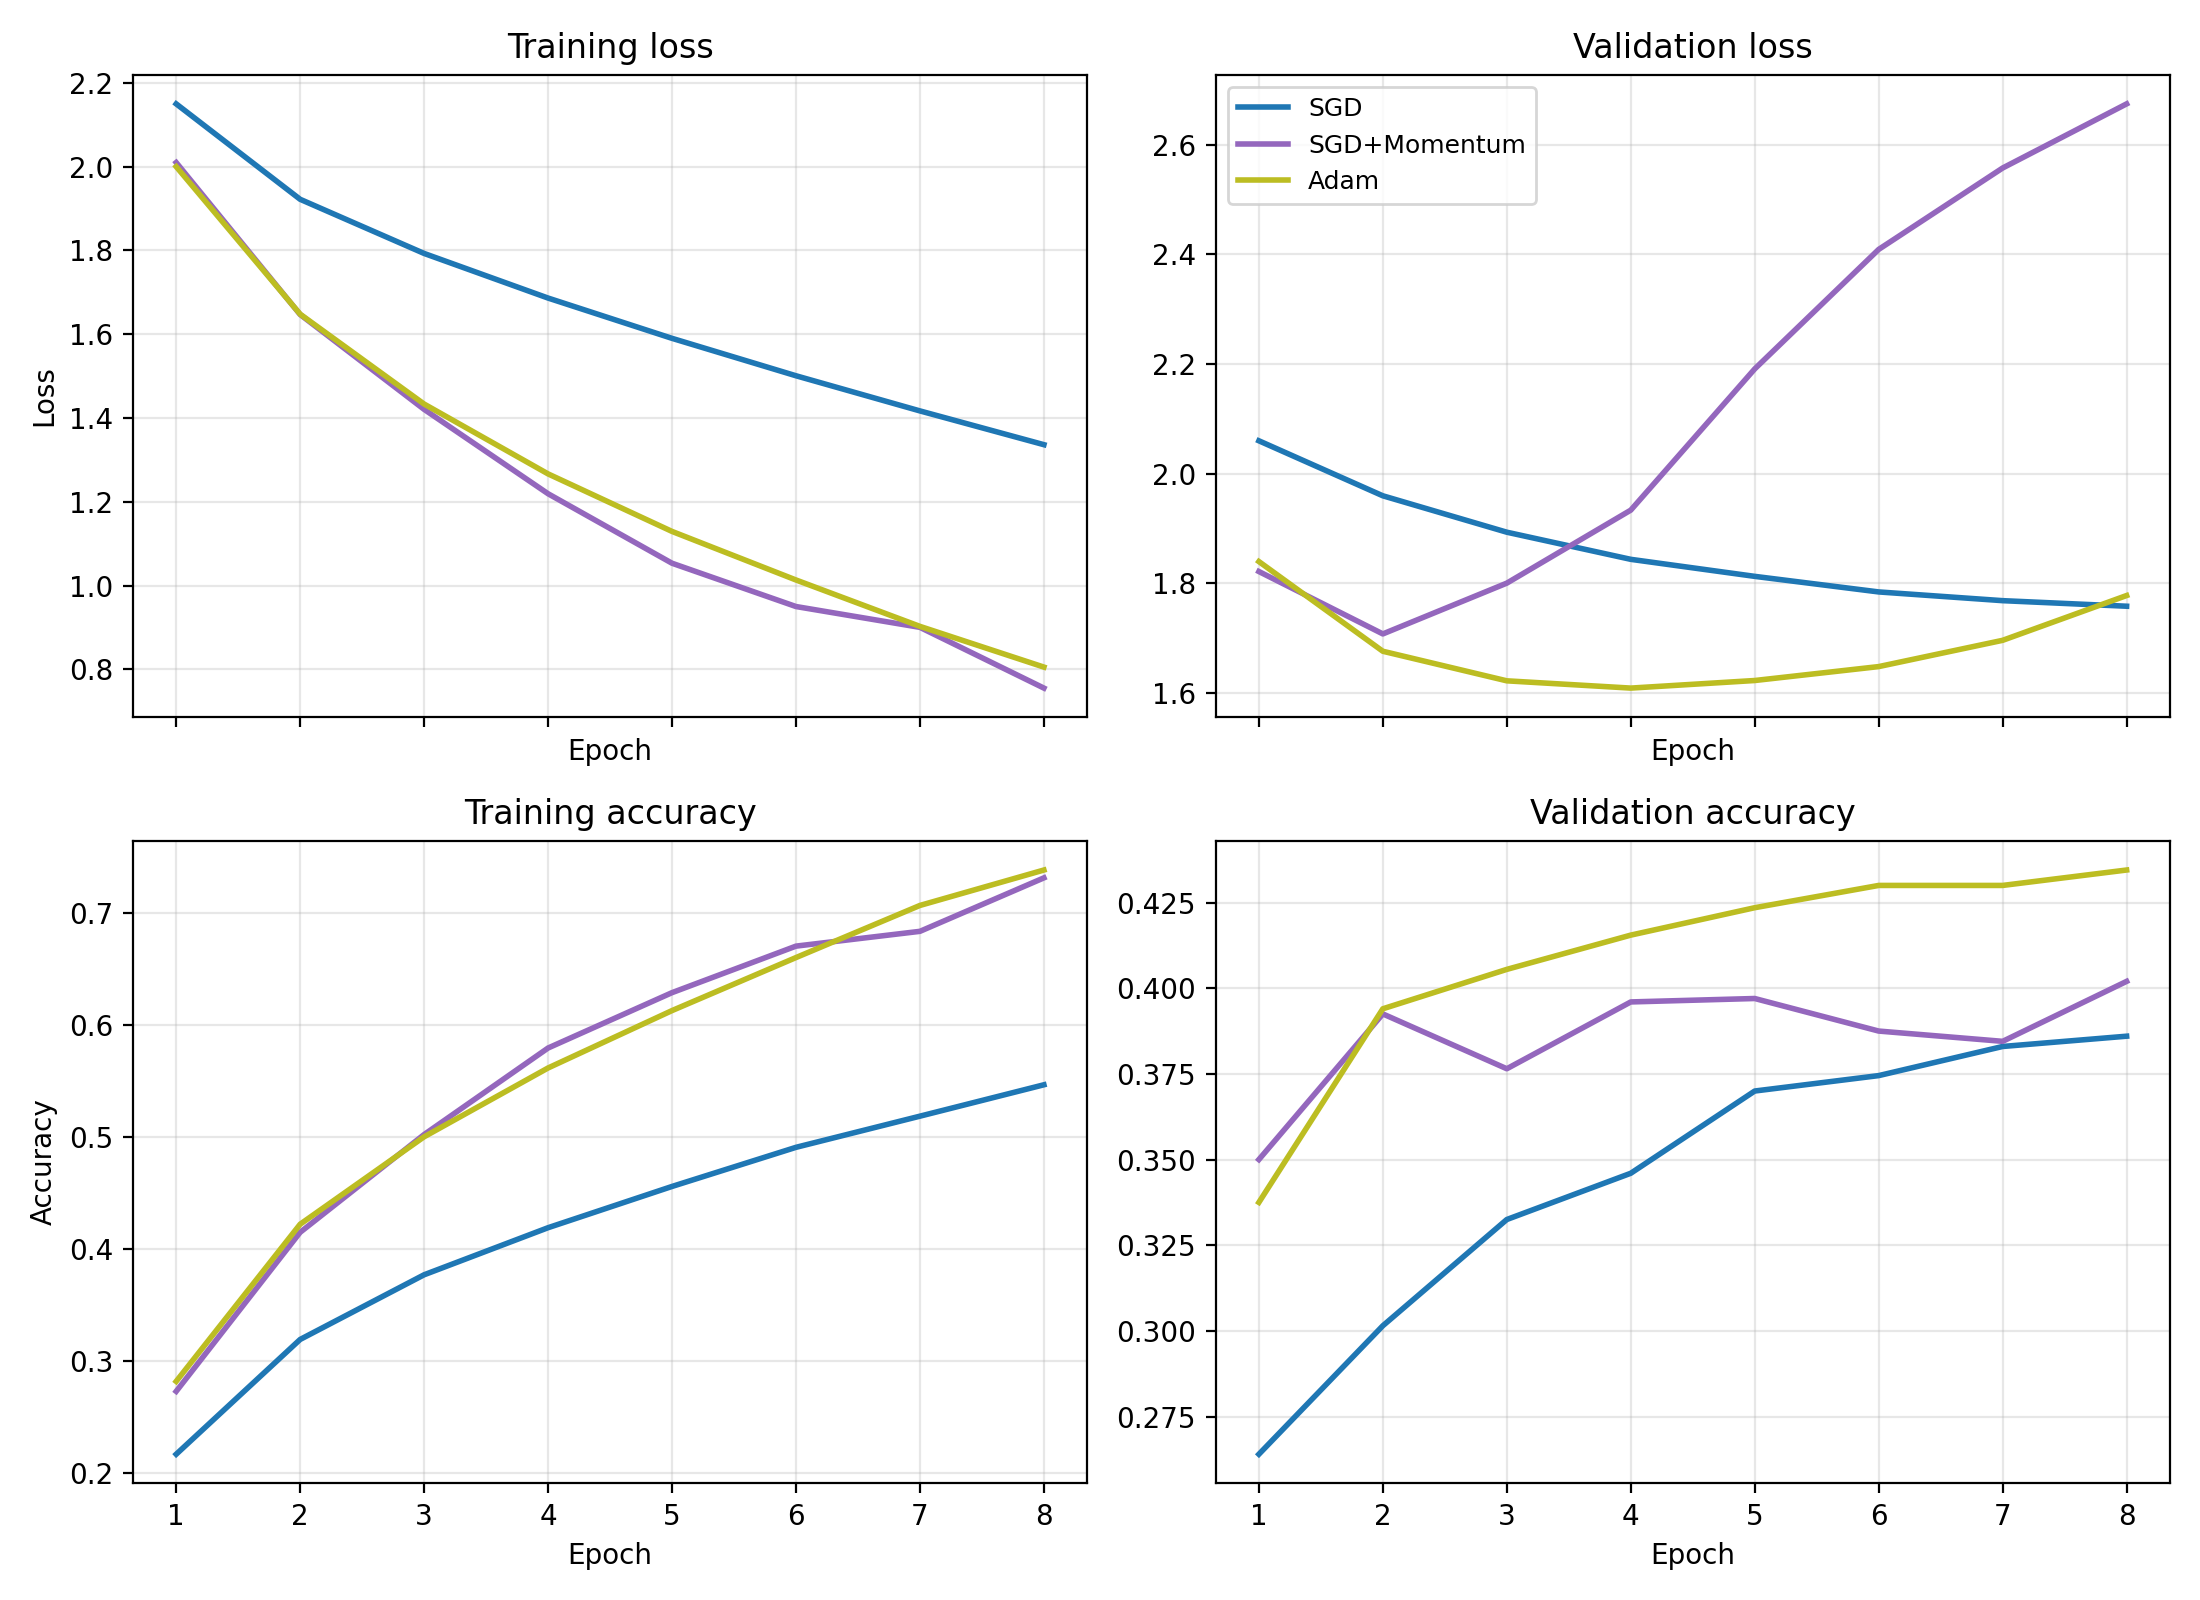

**Synth?se visuelle de la comparaison des optimiseurs**

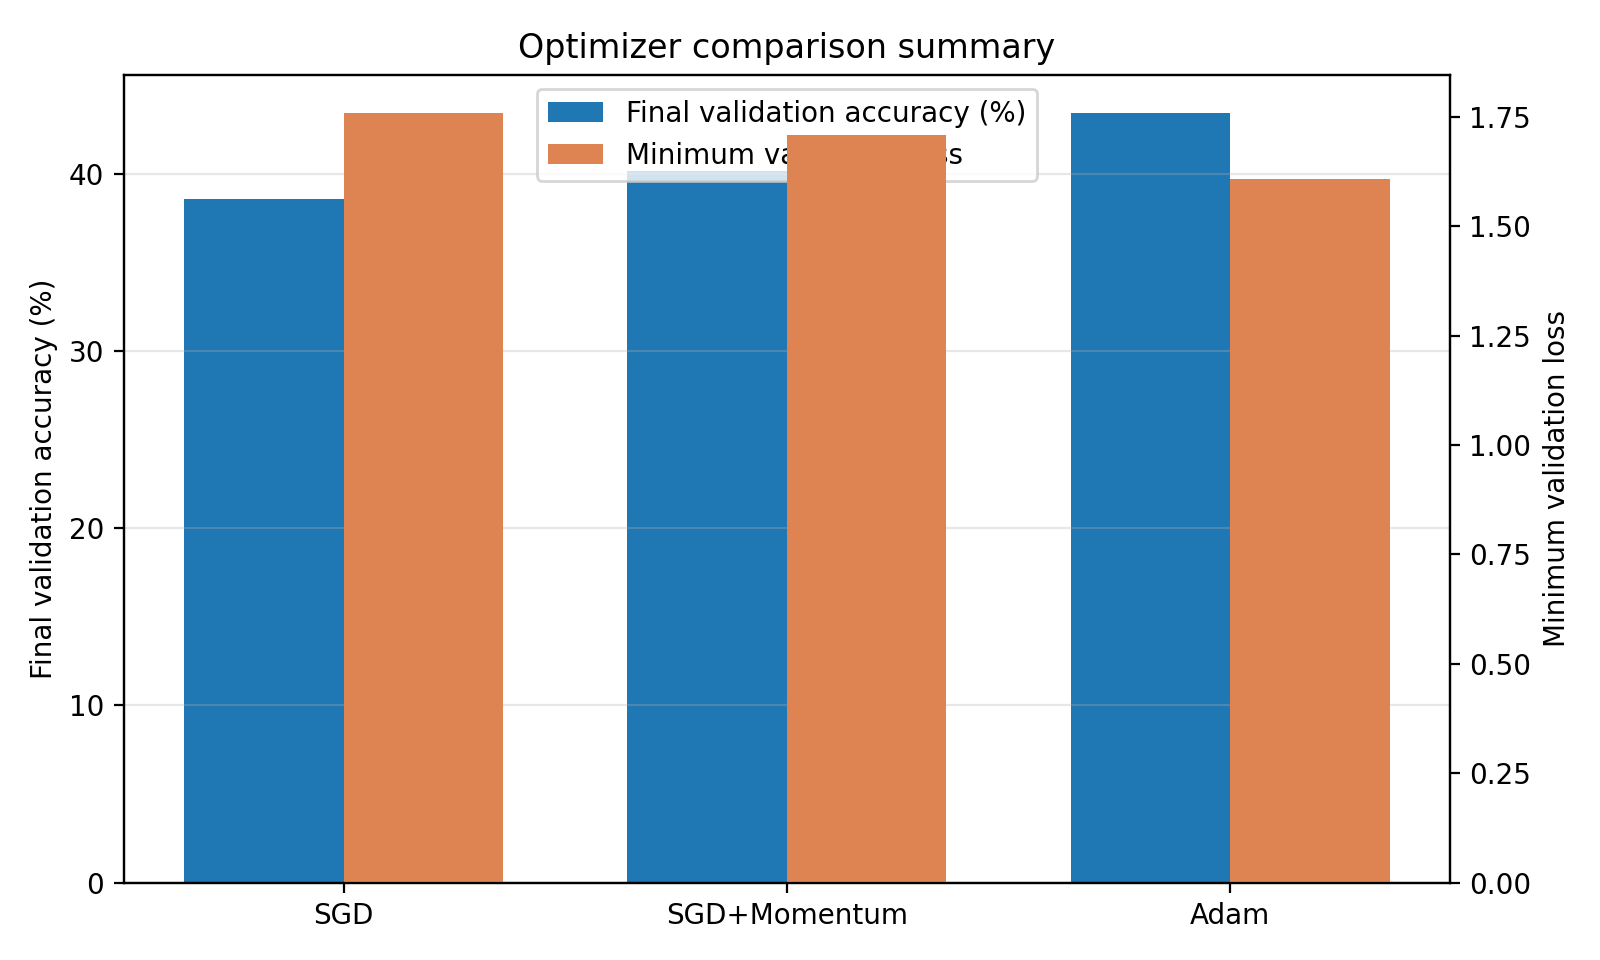

In [ ]:
display(Markdown("### V.4. Figures utilis?es dans la Section 4"))
image_paths = load_image_paths(figure_dir)
for key, title in [ 
    ("batch_step_time", "Temps moyen par step selon la taille du batch"),
    ("batch_epoch_time", "Temps moyen par epoch selon la taille du batch"),
    ("batch_curves", "Courbes d'apprentissage pour les batch sizes test?s"),
    ("optimizer_curves", "Courbes d'apprentissage pour les optimiseurs compar?s"),
    ("optimizer_summary", "Synth?se visuelle de la comparaison des optimiseurs"),
]:
    display(Markdown(f"**{title}**"))
    display(Image(filename=str(image_paths[key])))

### V.5. Observations principales

- ? budget fixe en epochs, les batch sizes les plus petits fournissent les meilleures performances de validation, tandis que les batch sizes les plus grands r?duisent surtout le temps moyen par epoch.
- Le batch size $16$ fournit le compromis le plus ?quilibr? entre stabilit?, co?t calculatoire et pr?cision finale sur le protocole CPU retenu.
- Adam domine la comparaison d'optimiseurs sur cette campagne, avec la meilleure accuracy finale de validation et la plus faible val. loss minimale.
- Le SGD avec Momentum acc?l?re la descente initiale, mais sa courbe de validation devient moins stable que celle d'Adam sur la fin de l'entra?nement.

# VI - Inventaire des hyperparametres pour la Section 5 du rapport

Cette section du notebook sert de point d'entree pour la Section 5 du rapport. La logique d'inventaire detaillee est placee dans `scripts/section5_hyperparameters.py`, mais le notebook conserve ici le diagnostic, la distinction entre parametres appris et hyperparametres, la classification par nature et les observations finales.

In [20]:
from IPython.display import Markdown, display

from scripts.section5_hyperparameters import (
    format_audit_markdown,
    format_classification_summary_markdown,
    format_inventory_markdown,
    format_non_hyperparameter_markdown,
    format_section5_conclusion_markdown,
    format_trainable_parameter_markdown,
    get_section5_payload,
)

In [21]:
section5_payload = get_section5_payload()

display(Markdown(format_audit_markdown()))
display(Markdown(format_trainable_parameter_markdown(section5_payload['trainable_summary'])))

### VI.1. Diagnostic

- L'inventaire doit distinguer les hyperparametres un par un, et non seulement par familles.
- Les quantites imposees par la tache, les hyperparametres ajustables et les conditions experimentales doivent etre separees plus strictement.
- Les hyperparametres d'optimisation deja etudies en Section 4 doivent etre rappeles ici sans dupliquer l'analyse experimentale complete.
- Le notebook et le helper peuvent fournir un inventaire analytique code par code, ancre explicitement dans les appels Keras utilises.

### VI.2. Distinction entre parametres appris et hyperparametres

Le modele contient **132010 parametres trainables**. Ces poids et biais sont ajustes par l'optimisation ; ils ne figurent donc pas dans l'inventaire des hyperparametres. La Section 5 distingue maintenant les hyperparametres du modele, les conditions experimentales externes et les constantes d'implementation.

| Couche | Nom | Parametres trainables |
| --- | --- | --- |
| Conv2D | conv2d_1 | 224 |
| Dropout | dropout_3 | 0 |
| MaxPooling2D | max_pooling2d_1 | 0 |
| Flatten | flatten_1 | 0 |
| Dense | dense_2 | 131136 |
| Dropout | dropout_4 | 0 |
| Dense | dense_3 | 650 |
| Dropout | dropout_5 | 0 |

In [22]:
display(Markdown(format_classification_summary_markdown(section5_payload['hyperparameters'])))
display(Markdown(format_inventory_markdown(section5_payload['hyperparameters'])))

### VI.3. Classification precise

| Nature precise | Nombre | Exemples |
| --- | --- | --- |
| structurel impose par la tache | 2 | input_shape, output_units |
| ajustable de conception | 9 | num_conv_layers, filters, kernel_size, padding... |
| entrainement | 10 | loss, optimizer, learning_rate, momentum... |
| regularisation | 2 | dropout_rate, l2_lambda |

### VI.4. Inventaire analytique des hyperparametres

#### Hyperparametres structurels, de conception et de regularisation
| Nom | Exemple de code | Nature precise | Valeur retenue | Influence attendue | Emplacement |
| --- | --- | --- | --- | --- | --- |
| input_shape | Input(shape=(32,32,3)) | structurel impose par la tache | 32 x 32 x 3 | fixe la forme des donnees d'entree et contraint la premiere couche du reseau | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| output_units | Dense(10, activation='softmax') | structurel impose par la tache | 10 | impose la dimension de sortie du classifieur et doit coïncider avec le nombre de classes | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| num_conv_layers | model.add(Conv2D(...)) | ajustable de conception | 1 couche convolutionnelle | controle la profondeur de l'extraction locale et la croissance du champ recepteur effectif | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| filters | Conv2D(filters=8, ...) | ajustable de conception | 8 | modifie la largeur de la representation convolutionnelle et le nombre de poids appris | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| kernel_size | Conv2D(..., kernel_size=(3,3), ...) | ajustable de conception | (3, 3) | controle le voisinage local explore et participe directement au champ recepteur | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| padding | Conv2D(..., padding='same') | ajustable de conception | same | preserve la resolution spatiale de sortie et conditionne la taille des tenseurs transmis aux couches suivantes | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| pool_size | MaxPool2D(pool_size=(2,2)) | ajustable de conception | (2, 2) | reduit la resolution spatiale, diminue le cout calculatoire et agrandit le champ recepteur effectif des couches profondes | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| conv_to_dense_bridge | Flatten() | ajustable de conception | Flatten | fixe la transition convolution-dense et donc la taille d'entree de la tete de classification | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| dense_units | Dense(64, activation='relu') | ajustable de conception | 64 | controle la largeur de la tete de classification et la capacite expressive de la partie dense | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| activation_hidden | activation='relu' | ajustable de conception | ReLU | introduit la non-linearite et limite en pratique l'attenuation du gradient dans les premieres couches | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| activation_output | activation='softmax' | ajustable de conception | softmax | rend la sortie interpretable comme distribution de probabilites sur les classes | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| dropout_rate | Dropout(0.0) | regularisation | 0.0 | si le taux etait strictement positif, il reduirait la co-adaptation des neurones et le risque de sur-apprentissage ; ici son effet empirique est nul | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| l2_lambda | kernel_regularizer=l2(0.00) | regularisation | 0.00 | si le coefficient etait positif, il penaliserait les poids trop grands et lisserait le modele ; ici son effet empirique est nul | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |

#### Hyperparametres d'entrainement
| Nom | Exemple de code | Nature precise | Valeur initiale | Valeurs explorees | Valeur retenue | Influence attendue | Emplacement |
| --- | --- | --- | --- | --- | --- | --- | --- |
| loss | compile(loss='categorical_crossentropy', ...) | entrainement | categorical_crossentropy | - | categorical_crossentropy | definit la quantite dont le gradient pilote l'apprentissage ; ici elle est adaptee a une sortie softmax et a des labels one-hot | TP3_CNN.ipynb / cell 20 ; scripts/section4_pipeline.py / run_training |
| optimizer | SGD(...), Adam(...) | entrainement | SGD | SGD, SGD+Momentum, Adam | comparaison explicite en Section 4 | modifie la dynamique de convergence, le lissage des gradients et la sensibilite au pas d'apprentissage | TP3_CNN.ipynb / cell 20 ; scripts/section4_pipeline.py / OPTIMIZER_CONFIGS + build_optimizer |
| learning_rate | SGD(learning_rate=0.01), Adam(learning_rate=0.001) | entrainement | 0.01 | 0.01 pour SGD et SGD+Momentum ; 0.001 pour Adam | 0.01 (SGD), 0.001 (Adam) | multiplie directement le gradient dans les mises a jour ; trop grand il destabilise la descente, trop faible il ralentit fortement la convergence | TP3_CNN.ipynb / cell 20 ; scripts/section4_pipeline.py / OPTIMIZER_CONFIGS + build_optimizer |
| momentum | SGD(..., momentum=0.0) / SGD(..., momentum=0.9) | entrainement | 0.0 | 0.0 et 0.9 | 0.9 pour la comparaison SGD+Momentum | ajoute une inertie directionnelle qui lisse les fluctuations du gradient entre deux mini-batches | TP3_CNN.ipynb / cell 20 ; scripts/section4_pipeline.py / OPTIMIZER_CONFIGS + build_optimizer |
| beta_1 | Adam(..., beta_1=0.9, ...) | entrainement | - | 0.9 | 0.9 | controle le lissage du premier moment dans Adam | scripts/section4_pipeline.py / OPTIMIZER_CONFIGS + build_optimizer |
| beta_2 | Adam(..., beta_2=0.999, ...) | entrainement | - | 0.999 | 0.999 | controle le lissage du second moment dans Adam | scripts/section4_pipeline.py / OPTIMIZER_CONFIGS + build_optimizer |
| adam_eta | Adam(..., epsilon=1e-7) | entrainement | - | 1e-7 | 1e-7 | stabilise numeriquement le denominateur de l'update d'Adam ; elle correspond au terme note eta dans le rapport | scripts/section4_pipeline.py / OPTIMIZER_CONFIGS + build_optimizer |
| batch_size | fit(..., batch_size=...) | entrainement | 32 | 8 ; {8,16,32,64,128} | 32 pour la baseline et l'etude optimiseurs ; grille {8,16,32,64,128} pour l'etude batch-size | agit sur le bruit du gradient, le nombre d'updates par epoch et le compromis entre stabilite et cout calculatoire | TP3_CNN.ipynb / cell 26 ; TP3_CNN.ipynb / cell 39 ; scripts/section4_pipeline.py / run_batch_size_study + run_optimizer_study |
| epochs | fit(..., epochs=...) | entrainement | 20 | 10 ; 8 | 8 pour les comparaisons controlees de la Section 4 | fixe le budget d'apprentissage en passages sur la base et conditionne le niveau de convergence atteint | TP3_CNN.ipynb / cell 26 ; TP3_CNN.ipynb / cell 39 ; scripts/section4_pipeline.py / run_batch_size_study + run_optimizer_study |
| shuffle | fit(..., shuffle=True) | entrainement | defaut Keras sur le notebook | True dans la pipeline reproductible | True | limite les effets d'ordre entre epochs et stabilise l'estimation du gradient stochastique | scripts/section4_pipeline.py / run_training |

In [4]:
display(Markdown(format_non_hyperparameter_markdown(section5_payload['excluded'])))
display(Markdown(format_section5_conclusion_markdown()))

### VI.5. Conditions externes et quantites ecartees

#### Conditions experimentales externes
| Nom | Exemple de code | Statut | Valeur | Influence | Emplacement |
| --- | --- | --- | --- | --- | --- |
| standardize | standardize(img_data) | pretraitement externe au modele | standardisation image par image et canal par canal | homogeneise l'echelle numerique des entrees et stabilise l'optimisation, sans constituer un hyperparametre du modele au sens strict | TP3_CNN.ipynb / cell 10 ; scripts/section4_pipeline.py / load_reduced_cifar10 |
| subset_sizes | n_training_samples, n_other_samples, n_valid | protocole externe au modele | 5000 train / 1000 validation / 1000 test | conditionne la quantite d'information disponible, la variance des mesures et le cout calculatoire, sans etre un hyperparametre sintonisable du modele | TP3_CNN.ipynb / cell 10 ; scripts/section4_pipeline.py / load_reduced_cifar10 |
| seeds | split_seed, TRAINING_SEEDS | controle de reproductibilite | 42 pour la partition ; 42 et 314 pour les campagnes controlees | agit sur la variance experimentale et la comparabilite des campagnes, sans modifier le modele lui-meme | scripts/section4_pipeline.py / run_batch_size_study + run_optimizer_study |

#### Quantites explicitement exclues de l'inventaire
| Nom | Exemple de code | Statut | Justification | Emplacement |
| --- | --- | --- | --- | --- |
| poids et biais appris | weights / biases trainables | parametre appris | ils encodent la solution apprise a partir des donnees et ne sont donc pas fixes a priori | TP3_CNN.ipynb / cell 16 ; scripts/section4_pipeline.py / build_model |
| logging_checkpoint | verbose, filepath, monitor, save_best_only, mode, save_freq | constante d'implementation | n'influence pas la dynamique d'apprentissage du modele | TP3_CNN.ipynb / cell 25 |
| metrics | metrics=['acc'] / ['accuracy'] | constante d'implementation | sert a evaluer l'apprentissage, mais ne modifie pas les mises a jour des poids | TP3_CNN.ipynb / cell 20 ; scripts/section4_pipeline.py / run_training |
| loss_reduction | CategoricalCrossentropy(reduction='sum_over_batch_size') | constante d'implementation | fixe une convention de reduction de la loss dans la pipeline, sans constituer un hyperparametre du modele au sens strict de la Section 5 | scripts/section4_pipeline.py / run_training |
| pipeline_visualisation | force_recompute, noms de fichiers, styles de figure | constante d'implementation | sans effet sur le modele ni sur la dynamique d'optimisation | TP3_CNN.ipynb / section 4 ; scripts/section4_visualization.py |

### VI.6. Observations principales

- L'inventaire analytique doit se faire hyperparametre par hyperparametre : code exact, nature precise, valeur initiale, valeurs explorees et influence attendue.
- Les hyperparametres structurels imposes par la tache doivent etre distingues des hyperparametres ajustables de conception et des hyperparametres d'entrainement.
- Les tailles de sous-ensembles, les graines et le standardize influencent l'experience, mais ils sont traites ici comme conditions experimentales externes et non comme hyperparametres du modele.

### VI.7. Observations de synthese

- Les poids et biais appris par retropropagation ne sont pas des hyperparametres ; ils constituent la solution ajuste au cours de l'entrainement.
- Les hyperparametres les plus structurants du projet sont la largeur du reseau, le choix de la loss, le choix de l'optimiseur, le learning rate, la taille du batch et le nombre d'epochs.
- Les quantites telles que `verbose`, `filepath` ou les options de checkpointing sont conservees comme constantes d'implementation et non comme hyperparametres du modele.